# Supplementary Figure S4: Correlations and Mutual Information

Supplementary Figure S4 compares boundary correlations and mutual information for undecorated and decorated MERA states.

This figure includes:

* (a) undecorated boundary correlations and mutual information versus chord distance
* (b) decorated boundary correlations and mutual information versus chord distance, with power-law fits

## Import Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox

import loadconfig as loco

import figure_helpers.correlations as correlations

from graph2grav.figure_hashing import save_figure_with_hash


## Make Figure

Plot the undecorated and decorated correlation comparison used in the supplement.

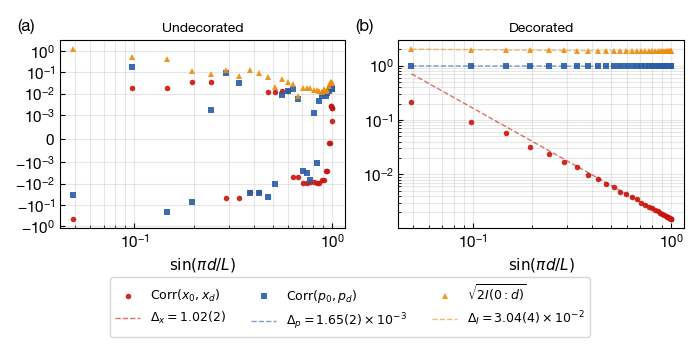

In [2]:
config = loco.reload()

# Side-by-side comparison
bbox = Bbox.from_bounds(0.0, 0, 7.0, 3.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(bbox.width, bbox.height))

depth = 6

squeezing = 0.01 # 10**(-2)

# Undecorated
correlations.plot_correlations_and_mutual_info(
    ax1,
    depth=depth,
    squeezing=squeezing,
    coupling_time=1.0,
    is_decorated=False,
    show_theory_lines=False,
    symlog=True,
)

subfigure_label_fontsize = config['subfigure-label']['font']['size']

ax1.set_title('Undecorated', fontsize=10)
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, fontsize=subfigure_label_fontsize)

# Decorated - fit x, p, and MI with scaling dimensions in legend
correlations.plot_correlations_and_mutual_info(
    ax2,
    depth=depth,
    squeezing=squeezing,
    coupling_time=1.0,
    is_decorated=True,
    show_theory_lines=False,
    fit_x=True,
    fit_p=True,
    fit_mi=True,
    fraction_to_exclude_x=1/3,
    fraction_to_exclude_p=1/3,
    fraction_to_exclude_mi=1/3,
)
ax2.set_title('Decorated', fontsize=10)
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, fontsize=subfigure_label_fontsize)

# Add shared legend below plots (use ax2 handles to include fits)
handles, labels = ax2.get_legend_handles_labels()
permutation = [0, 3, 1, 4, 2, 5]  # Rearrange to group x, p, MI
fig.legend(
    [handles[i] for i in permutation], [labels[i] for i in permutation],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    fontsize=9,
    frameon=True
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.35)  # Make room for legend

if export_figure := True:
    save_figure_with_hash(fig, f'figures/supplementary-figure_correlations-comparison-depth-{depth}.pdf')


## Diagnostic: Mutual-Information Fits

Compare mutual-information scaling-dimension fits for decorated and undecorated graphs. This diagnostic is not part of the paper figure.

Undecorated: Δ_I/2 = 1.448
Decorated:   Δ_I/2 = 0.032


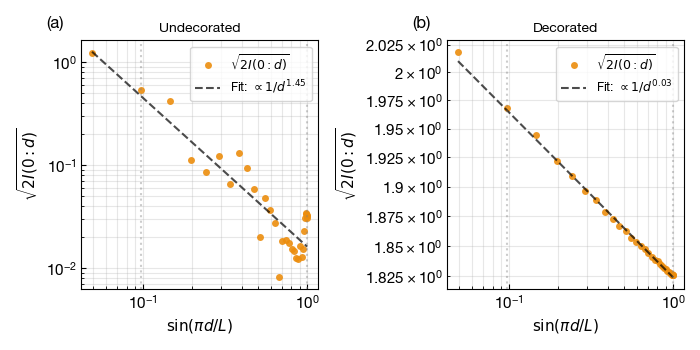

In [ ]:
config = loco.reload()

# Side-by-side comparison
bbox = Bbox.from_bounds(0.0, 0, 7.0, 3.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(bbox.width, bbox.height))

depth = 6
squeezing = 0.01

subfigure_label_fontsize = config['subfigure-label']['font']['size']

# Undecorated
delta_undec = correlations.plot_mutual_info_with_fit(
    ax1,
    depth=depth,
    squeezing=squeezing,
    coupling_time=1.0,
    is_decorated=False,
    fraction_to_exclude=0,
)
ax1.set_title(f'Undecorated', fontsize=10)
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, fontsize=subfigure_label_fontsize)

# Decorated
delta_dec = correlations.plot_mutual_info_with_fit(
    ax2,
    depth=depth,
    squeezing=squeezing,
    coupling_time=1.0,
    is_decorated=True,
    fraction_to_exclude=0,
)
ax2.set_title(f'Decorated', fontsize=10)
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, fontsize=subfigure_label_fontsize)

plt.tight_layout()

print(f"Undecorated: Δ_I/2 = {delta_undec:.3f}")
print(f"Decorated:   Δ_I/2 = {delta_dec:.3f}")

# This is not one of the figures we export for the paper.
if export_figure := False:
    save_figure_with_hash(fig, 'figures/supplementary-figure_mi-fit-comparison.pdf')


## Scratch Cells